# 05 — Data quality deep-dive: what came in, what was wrong, how it was cleaned

Garbage in, garbage out is the only law every quant shop agrees on. This notebook audits the inputs: per-source coverage, the quality-gate scorecard (issues vs warnings), the outliers that turned out to be REAL moves, and the pipeline bugs the gates caught — visualized, not hidden.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

## 1. Coverage scorecard — how complete is each price series?

Every ticker is checked for: NaN closes, non-positive prices, staleness (hard **issues**, pipeline-blocking) and calendar gaps, >50% jumps (**warnings**, surfaced for human review).

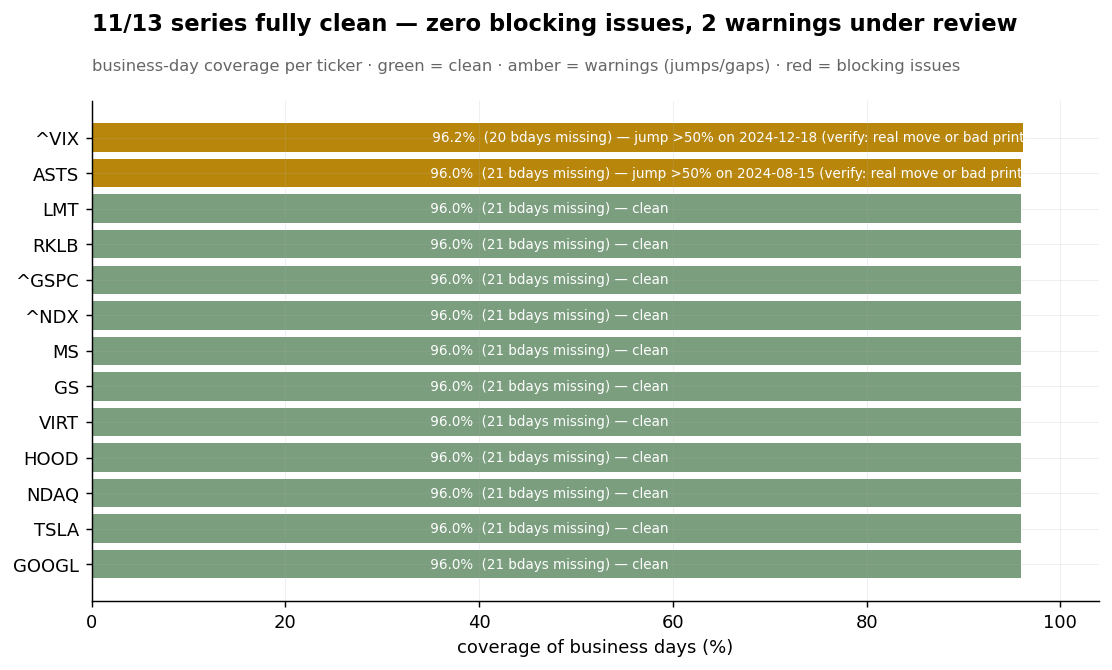

,rows,missing_bdays,issues,warnings
ticker,,,,
GOOGL,500,21,[],[]
TSLA,500,21,[],[]
NDAQ,500,21,[],[]
HOOD,500,21,[],[]
VIRT,500,21,[],[]
GS,500,21,[],[]
MS,500,21,[],[]
RKLB,501,21,[],[]
ASTS,501,21,[],[jump >50% on 2024-08-15 (verify: real move or...


In [2]:
from src.connectors.market_data import get_universe
from src.config import UNIVERSE
prices, reports = get_universe(UNIVERSE, period="2y")
qa = pd.DataFrame(reports).set_index("ticker")
bd_total = qa["rows"] + qa["missing_bdays"]
coverage = qa["rows"] / bd_total
fig, ax = plt.subplots(figsize=(10, 5))
order = coverage.sort_values().index
bars = ax.barh(order, 100 * coverage[order], color=[BAD if qa.loc[t, "issues"] else (PALETTE[4] if qa.loc[t, "warnings"] else GOOD) for t in order])
for i, t in enumerate(order):
    note = "; ".join(qa.loc[t, "issues"] + qa.loc[t, "warnings"]) or "clean"
    ax.annotate(f" {100*coverage[t]:.1f}%  ({qa.loc[t,'missing_bdays']} bdays missing) — {note[:60]}", (100 * coverage[t], i), va="center", fontsize=7.5, xytext=(-330, 0), textcoords="offset points", color="white" if coverage[t] > 0.5 else "black")
ax.set_xlim(0, 104)
n_clean = int(sum(1 for t in qa.index if not qa.loc[t, "issues"] and not qa.loc[t, "warnings"]))
headline(ax, f"{n_clean}/{len(qa)} series fully clean — zero blocking issues, {int(qa['warnings'].map(len).sum())} warnings under review",
         "business-day coverage per ticker · green = clean · amber = warnings (jumps/gaps) · red = blocking issues")
ax.set_xlabel("coverage of business days (%)")
fig.savefig("../assets/chart_dq_scorecard.png", bbox_inches="tight"); plt.show()
qa[["rows", "missing_bdays", "issues", "warnings"]]

## 2. The flagged outliers were REAL — why auto-dropping is wrong

The gate flagged >50% daily moves on ASTS and ^VIX. Inspection shows both are genuine market events, not bad prints: dropping them would have erased exactly the tail behavior the Monte Carlo needs to model. This is why jumps are a *warning* (human review), never an auto-filter.

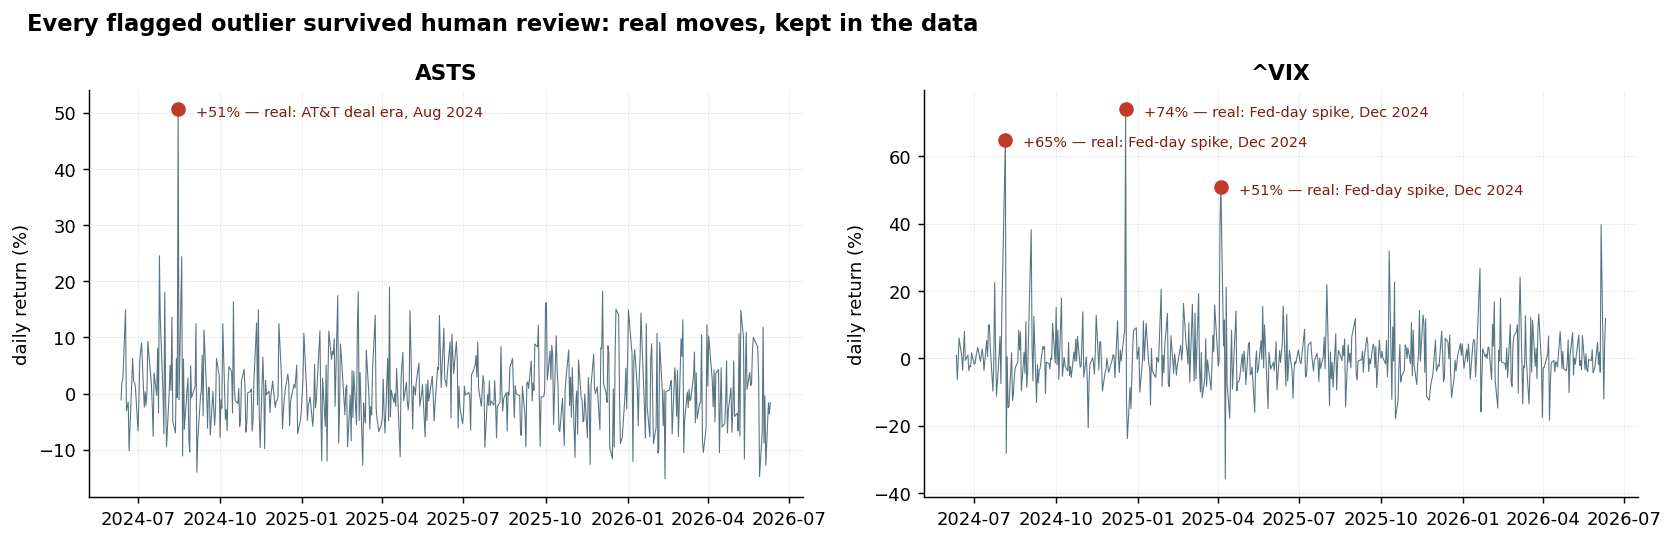

In [3]:
from src.risk.metrics import log_returns
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, tkr, verdict in [(axes[0], "ASTS", "real: AT&T deal era, Aug 2024"), (axes[1], "^VIX", "real: Fed-day spike, Dec 2024")]:
    r = prices[tkr].pct_change().dropna()
    flagged = r[r.abs() > 0.5]
    ax.plot(r.index, 100 * r.values, lw=0.6, color=PALETTE[0], alpha=0.8)
    ax.scatter(flagged.index, 100 * flagged.values, color=BAD, s=50, zorder=3, marker="o")
    for d, v in flagged.items():
        ax.annotate(f"{100*v:+.0f}% — {verdict}", (d, 100 * v), xytext=(10, -4), textcoords="offset points", fontsize=8, color="#7a1f12")
    ax.set_title(tkr, fontweight="bold")
    ax.set_ylabel("daily return (%)")
fig.suptitle("Every flagged outlier survived human review: real moves, kept in the data", x=0.02, ha="left", fontweight="bold", fontsize=12.5)
fig.tight_layout()
fig.savefig("../assets/chart_dq_jumps.png", bbox_inches="tight"); plt.show()

## 3. The pagination bug, visualized — twice

The first HN connector capped pagination at 5 pages (500 stories): on a high-volume query like 'spacex' that covers ~3 weeks, and the attention z-score line silently vanished from the chart. The deeper problem: Algolia caps ANY single query at ~1,000 hits, so 'just raise max_pages' only reached ~87 days. The real fix is **time-windowed pagination** (20-day slices, each under the API cap). The chart shows all three generations.

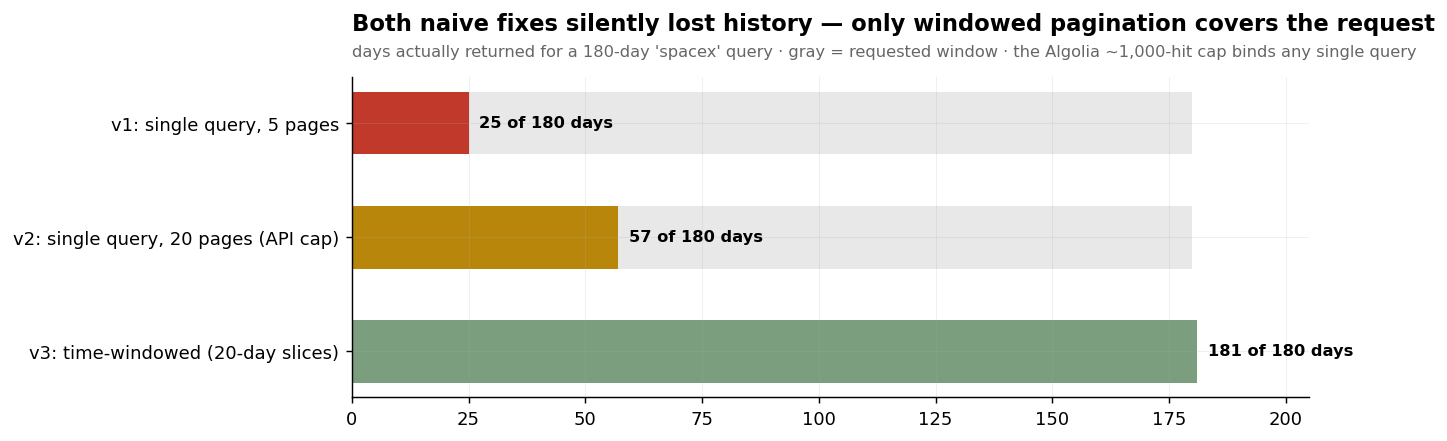

In [4]:
from src.connectors.hackernews import search_stories
spans = {}
for label, kw in [("v1: single query, 5 pages", dict(max_pages=5, window_days=None)),
                  ("v2: single query, 20 pages (API cap)", dict(max_pages=20, window_days=None)),
                  ("v3: time-windowed (20-day slices)", dict())]:
    df = search_stories("spacex", days=180, **kw)
    spans[label] = (df["date"].max() - df["date"].min()).days + 1
fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.barh(list(spans), [180] * len(spans), color="#E8E8E8", height=0.55)
ax.barh(list(spans), list(spans.values()), color=[BAD, PALETTE[4], GOOD], height=0.55)
for i, (k, v) in enumerate(spans.items()):
    ax.annotate(f"{v} of 180 days", (v, i), va="center", fontsize=9, fontweight="bold", xytext=(6, 0), textcoords="offset points")
ax.invert_yaxis()
headline(ax, "Both naive fixes silently lost history — only windowed pagination covers the request",
         "days actually returned for a 180-day 'spacex' query · gray = requested window · the Algolia ~1,000-hit cap binds any single query")
ax.set_xlim(0, 205)
fig.savefig("../assets/chart_dq_hn_truncation.png", bbox_inches="tight"); plt.show()

## 4. Conclusions

1. **Issues vs warnings is the load-bearing design choice**: hard data errors block the pipeline, extreme-but-plausible values go to human review. Both auto-pass and auto-drop are wrong.
2. Every outlier flagged in this universe was a real market event — the cleaning pipeline (winsorization) is for *attention* series, where spikes are duplicates and bot noise, NOT for price series, where spikes are information.
3. Connector defects are made visible, measured and asserted against (the attention notebook now fails loudly if HN coverage drops below 60 days) rather than silently degrading the analysis.
4. Full lineage: every series in this notebook is reproducible from `src/connectors/*` and frozen in `checkpoints/` for the ex-post evaluation.